# TP3 — Bin Packing : Métaheuristiques (SA & Tabu Search)

**Objectif (demande de l'enseignant)** : construire des **tuners de paramètres** pour :
- **Simulated Annealing (SA)**
- **Tabu Search (TS)**

Les tuners doivent :
1) **Trouver les meilleurs hyperparamètres** sur un petit ensemble d'instances.
2) **Tracer des graphes** montrant l'effet de chaque hyperparamètre (variation **un par un**, les autres fixés).


---

## 1) Mise en place


In [1]:
# ── Imports & path setup ─────────────────────────────────────────────────────
%matplotlib inline

import itertools
import random
import sys
import time
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path(".").resolve()
if (NOTEBOOK_DIR / "solver.py").exists():
    SOLVER_DIR = NOTEBOOK_DIR
    PROJECT_ROOT = NOTEBOOK_DIR.parent
elif (NOTEBOOK_DIR / "3_metaheuristics" / "solver.py").exists():
    PROJECT_ROOT = NOTEBOOK_DIR
    SOLVER_DIR = NOTEBOOK_DIR / "3_metaheuristics"
else:
    raise FileNotFoundError("Impossible de localiser 3_metaheuristics/solver.py")

for path in [PROJECT_ROOT, SOLVER_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import solver as meta
from benchmark import DATASET_REGISTRY, BenchmarkInstance

print("Imports OK — solver:", SOLVER_DIR, "| root:", PROJECT_ROOT)


Imports OK — solver: /home/amine/Documents/Projects/optimization/3_metaheuristics | root: /home/amine/Documents/Projects/optimization


---

## 2) Charger un petit set d'instances (tuning workload)

Pour que le notebook reste **rapide**, on tune sur un nombre limité d'instances + quelques seeds.
Vous pouvez augmenter ces paramètres pour un tuning plus robuste.


In [2]:
# ── Paramètres de workload (à ajuster) ───────────────────────────────────────
DATASET_KEY = "falkenauer-t"  # scholl-1 | scholl-2 | scholl-3 | falkenauer-t | falkenauer-u
MAX_ITEMS = 60                # filtre : ne garde que les instances avec n <= MAX_ITEMS
N_INSTANCES = 5               # nombre d'instances utilisées pour le tuning
SEEDS = [0, 1, 2]             # répétitions (aléatoire) par instance


def load_instances(
    dataset_key: str,
    *,
    max_items: int | None = None,
    num_items: int | None = None,
    limit: int | None = None,
) -> list[BenchmarkInstance]:
    dataset = DATASET_REGISTRY[dataset_key]
    instances: list[BenchmarkInstance] = []
    for filepath in dataset.directory.glob(dataset.glob):
        try:
            inst = dataset.parser(filepath, dataset.key)
        except Exception:
            continue
        if num_items is not None and inst.num_items != num_items:
            continue
        if max_items is not None and inst.num_items > max_items:
            continue
        instances.append(inst)
    instances.sort(key=lambda i: (i.num_items, i.name))
    if limit is not None:
        instances = instances[:limit]
    return instances


def lower_bound(inst: BenchmarkInstance) -> int:
    return ceil(sum(inst.sizes) / inst.bin_capacity)


all_instances = load_instances(DATASET_KEY, max_items=MAX_ITEMS)
tuning_instances = all_instances[:N_INSTANCES]

print(
    f"Dataset={DATASET_KEY} | instances loaded={len(all_instances)} | tuning set={len(tuning_instances)}"
)
pd.DataFrame(
    [
        {
            "instance": i.name,
            "n": i.num_items,
            "capacity": i.bin_capacity,
            "lb": lower_bound(i),
        }
        for i in tuning_instances
    ]
)


Dataset=falkenauer-t | instances loaded=20 | tuning set=5


,instance,n,capacity,lb
0,Falkenauer_t60_00,60,1000,20
1,Falkenauer_t60_01,60,1000,20
2,Falkenauer_t60_02,60,1000,20
3,Falkenauer_t60_03,60,1000,20
4,Falkenauer_t60_04,60,1000,20


---

## 3) Helpers d'évaluation (métriques + exécution)

On minimise d'abord **le nombre de bins**, puis on utilise le **score** (fonction interne du solver) comme tie-break.


In [3]:
SORT_COLS = ["bins_mean", "score_mean", "time_mean"]


def evaluate(
    *,
    method: str,
    instances: list[BenchmarkInstance],
    seeds: list[int],
    run_one,
) -> pd.DataFrame:
    rows: list[dict] = []
    for inst in instances:
        for seed in seeds:
            out = run_one(inst, seed)
            rows.append(
                {
                    "method": method,
                    "instance": inst.name,
                    "n": inst.num_items,
                    "capacity": inst.bin_capacity,
                    "lb": lower_bound(inst),
                    "seed": seed,
                    **out,
                }
            )
    return pd.DataFrame(rows)


def summarize_runs(df_runs: pd.DataFrame) -> dict:
    return {
        "bins_mean": float(df_runs["bins"].mean()),
        "bins_std": float(df_runs["bins"].std(ddof=0) if len(df_runs) > 1 else 0.0),
        "score_mean": float(df_runs["score"].mean()),
        "score_std": float(df_runs["score"].std(ddof=0) if len(df_runs) > 1 else 0.0),
        "time_mean": float(df_runs["elapsed"].mean()),
    }


def tune_one_by_one(
    *,
    label: str,
    base_params: dict[str, object],
    grid: dict[str, list],
    eval_params,
    rounds: int = 1,
    sort_cols: list[str] = SORT_COLS,
) -> tuple[dict[str, object], pd.DataFrame]:
    """Tuning one-by-one: on optimise un paramètre à la fois, les autres fixés."""
    current: dict[str, object] = dict(base_params)
    history: list[dict] = []

    for r in range(1, rounds + 1):
        print(f"[{label}] Round {r}/{rounds} — start: {current}")
        for param, values in grid.items():
            rows: list[dict] = []
            for v in values:
                params = dict(current)
                params[param] = v
                summary = eval_params(params)
                rows.append({"round": r, "param": param, "value": v, **params, **summary})

            df = pd.DataFrame(rows).sort_values(sort_cols, ignore_index=True)
            best_value = df.loc[0, "value"]
            current[param] = best_value
            history.extend(rows)

            print(
                f"  - best {param}={best_value} | bins_mean={df.loc[0,'bins_mean']:.3f} | time_mean={df.loc[0,'time_mean']:.3f}s"
            )

    return current, pd.DataFrame(history)


def plot_sensitivity(df: pd.DataFrame, *, title_prefix: str = "") -> None:
    for param in df["param"].unique():
        sub = df[df["param"] == param].copy().sort_values("value")

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.errorbar(sub["value"], sub["bins_mean"], yerr=sub["bins_std"], marker="o", capsize=3)
        ax.set_title(f"{title_prefix}{param} → bins (mean±std)")
        ax.set_xlabel(param)
        ax.set_ylabel("Bins utilisés")
        ax.grid(True, alpha=0.3)

        if "temperature" in param:
            ax.set_xscale("log")
        display(fig)
        plt.close(fig)


def make_sa_config(params: dict[str, object]) -> meta._SimulatedAnnealingConfig:
    """Cast explicite: évite les bugs pandas (ex: max_iterations en float)."""
    return meta._SimulatedAnnealingConfig(
        max_iterations=int(params["max_iterations"]),
        cooling_rate=float(params["cooling_rate"]),
        min_temperature=float(params["min_temperature"]),
    )


def run_sa(inst: BenchmarkInstance, seed: int, config: meta._SimulatedAnnealingConfig) -> dict:
    random.seed(seed)
    core = meta._MetaheuristicCore(list(inst.sizes), inst.bin_capacity)
    solver = meta._SimulatedAnnealingSolver(core)
    start = time.perf_counter()
    sol = solver._solve(config)  # accès volontaire au "private" pour tuner
    elapsed = time.perf_counter() - start
    score = core.score(sol.final_bin_loads)
    return {"bins": sol.total_bins_used, "score": score, "elapsed": elapsed}


def run_tabu_custom(
    inst: BenchmarkInstance,
    seed: int,
    *,
    tabu_tenure: int,
    max_iterations: int,
    max_candidates: int,
    patience_ratio: float = 0.28,
) -> dict:
    """Tabu Search basique (TS) avec hyperparamètres explicités."""

    random.seed(seed)
    core = meta._MetaheuristicCore(list(inst.sizes), inst.bin_capacity)
    ts = meta._TabuSearchSolver(core)

    if not core.item_sizes:
        return {"bins": 0, "score": 0, "elapsed": 0.0}

    start = time.perf_counter()

    current_loads, current_assignments = core.simulate_initial_solution()
    current_cost = core.score(current_loads)
    lb = ceil(sum(core.item_sizes) / core.bin_capacity)

    best_loads = list(current_loads)
    best_assignments = [list(items) for items in current_assignments]
    best_cost = current_cost

    tabu_until: dict[tuple[int, int], int] = {}
    move_frequency: dict[tuple[int, int], int] = {}

    patience = max(50, int(patience_ratio * max_iterations))
    no_improve = 0

    for iteration in range(1, max_iterations + 1):
        move, cand_loads, cand_assignments, cand_cost = ts._select_best_tabu_neighbor(
            current_loads=current_loads,
            current_assignments=current_assignments,
            tabu_until=tabu_until,
            move_frequency=move_frequency,
            iteration=iteration,
            tabu_tenure=tabu_tenure,
            best_global_cost=best_cost,
            diversification_weight=0.0,
            max_candidates=max_candidates,
        )

        current_loads = cand_loads
        current_assignments = cand_assignments
        current_cost = cand_cost
        ts._update_tabu_memory(tabu_until, move, iteration, tabu_tenure)

        if current_cost < best_cost:
            best_cost = current_cost
            best_loads = list(current_loads)
            best_assignments = [list(items) for items in current_assignments]
            no_improve = 0
        else:
            no_improve += 1

        if len(best_loads) <= lb:
            break
        if no_improve >= patience:
            break

    sol = core.build_solution(best_loads, best_assignments)
    elapsed = time.perf_counter() - start
    score = core.score(sol.final_bin_loads)
    return {"bins": sol.total_bins_used, "score": score, "elapsed": elapsed}


---

## 4) Tuner — Simulated Annealing (SA)

Hyperparamètres choisis :
- `max_iterations`
- `cooling_rate`
- `min_temperature`

Tuning : **one-by-one** (un paramètre à la fois, les autres fixés).


In [4]:
SA_GRID = {
    "max_iterations": [2_000, 5_000, 8_000],
    "cooling_rate": [0.97, 0.98, 0.99, 0.995],
    "min_temperature": [1e-4, 1e-3],
}

SA_ROUNDS = 1  # augmenter (ex: 2) si vous voulez refaire des passes


def eval_sa_params(params: dict[str, object]) -> dict:
    config = make_sa_config(params)
    df_runs = evaluate(
        method="SA",
        instances=tuning_instances,
        seeds=SEEDS,
        run_one=lambda inst, seed: run_sa(inst, seed, config),
    )
    return summarize_runs(df_runs)


sa_base = {k: SA_GRID[k][0] for k in SA_GRID}
best_sa_params, sa_tuning_log = tune_one_by_one(
    label="SA", base_params=sa_base, grid=SA_GRID, eval_params=eval_sa_params, rounds=SA_ROUNDS
)
best_sa_summary = eval_sa_params(best_sa_params)

print("Best SA params:", best_sa_params)
display(best_sa_summary)
display(sa_tuning_log.sort_values(SORT_COLS, ignore_index=True).head(12))


[SA] Round 1/1 — start: {'max_iterations': 2000, 'cooling_rate': 0.97, 'min_temperature': 0.0001}
  - best max_iterations=8000 | bins_mean=23.200 | time_mean=0.113s
  - best cooling_rate=0.97 | bins_mean=23.200 | time_mean=0.115s
  - best min_temperature=0.0001 | bins_mean=23.200 | time_mean=0.113s
Best SA params: {'max_iterations': np.int64(8000), 'cooling_rate': np.float64(0.97), 'min_temperature': np.float64(0.0001)}


{'bins_mean': 23.2,
 'bins_std': 0.4,
 'score_mean': 682161.8666666667,
 'score_std': 112957.93555353052,
 'time_mean': 0.11175017453315376}

,round,param,value,max_iterations,cooling_rate,min_temperature,bins_mean,bins_std,score_mean,score_std,time_mean
0,1,min_temperature,0.0001,8000,0.970,0.0001,23.2,0.4,682161.866667,112957.935554,0.112648
1,1,max_iterations,8000.0000,8000,0.970,0.0001,23.2,0.4,682161.866667,112957.935554,0.112900
2,1,min_temperature,0.0010,8000,0.970,0.0010,23.2,0.4,682161.866667,112957.935554,0.114575
3,1,cooling_rate,0.9700,8000,0.970,0.0001,23.2,0.4,682161.866667,112957.935554,0.114771
4,1,cooling_rate,0.9800,8000,0.980,0.0001,23.2,0.4,682184.400000,112972.754618,0.112080
5,1,cooling_rate,0.9900,8000,0.990,0.0001,23.2,0.4,682203.333333,112924.715579,0.110984
6,1,cooling_rate,0.9950,8000,0.995,0.0001,23.2,0.4,682225.333333,112920.047747,0.111453
7,1,max_iterations,5000.0000,5000,0.970,0.0001,23.2,0.4,682371.066667,113146.950806,0.071333
8,1,max_iterations,2000.0000,2000,0.970,0.0001,23.2,0.4,684068.266667,113633.614780,0.029884


,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,max_iterations,2000.0000,23.2,0.4,684068.266667,113633.614780,0.029318
1,max_iterations,5000.0000,23.2,0.4,682371.066667,113146.950806,0.068635
2,max_iterations,8000.0000,23.2,0.4,682161.866667,112957.935554,0.112415
3,cooling_rate,0.9700,23.2,0.4,682161.866667,112957.935554,0.109850
4,cooling_rate,0.9800,23.2,0.4,682184.400000,112972.754618,0.111920
5,cooling_rate,0.9900,23.2,0.4,682203.333333,112924.715579,0.111163
6,cooling_rate,0.9950,23.2,0.4,682225.333333,112920.047747,0.111225
7,min_temperature,0.0001,23.2,0.4,682161.866667,112957.935554,0.110215
8,min_temperature,0.0010,23.2,0.4,682161.866667,112957.935554,0.111055


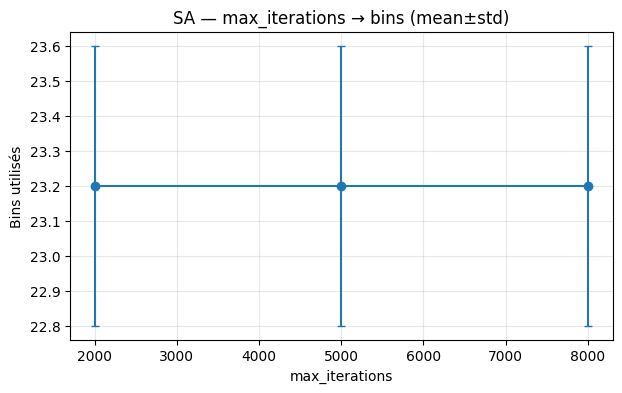

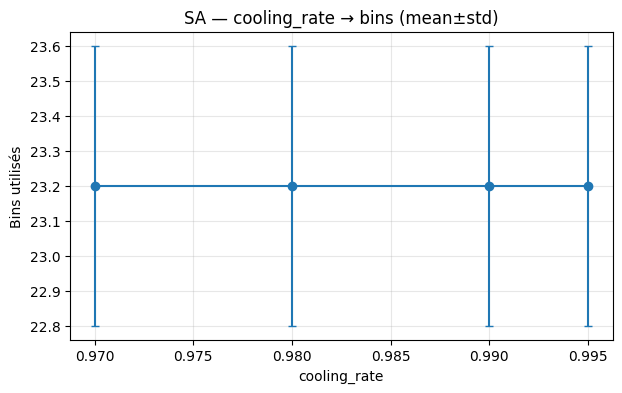

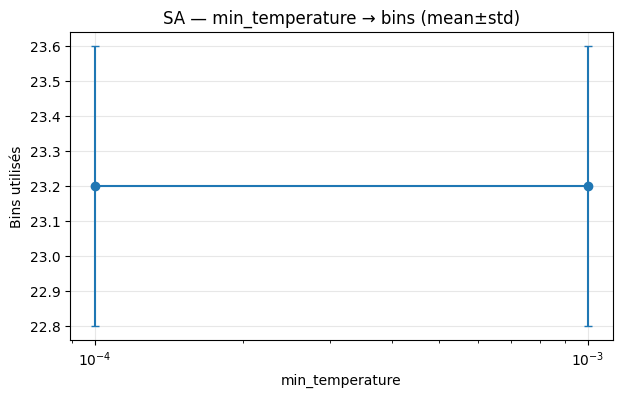

In [5]:
# ── Sensibilité : on varie 1 paramètre, les autres fixés au best ─────────────
sa_sens_rows: list[dict] = []
for param, values in SA_GRID.items():
    for v in values:
        params = dict(best_sa_params)
        params[param] = v
        config = make_sa_config(params)

        df_runs = evaluate(
            method="SA",
            instances=tuning_instances,
            seeds=SEEDS,
            run_one=lambda inst, seed: run_sa(inst, seed, config),
        )
        sa_sens_rows.append({"param": param, "value": v, **summarize_runs(df_runs)})

sa_sensitivity = pd.DataFrame(sa_sens_rows)
display(sa_sensitivity)
plot_sensitivity(sa_sensitivity, title_prefix="SA — ")


---

## 5) Tuner — Tabu Search (TS)

Hyperparamètres choisis :
- `tabu_tenure` (durée tabu)
- `max_candidates` (taille du voisinage échantillonné)
- `max_iterations`

Tuning : **one-by-one** (un paramètre à la fois, les autres fixés).


In [6]:
TS_GRID = {
    "tabu_tenure": [4, 6, 8, 10],
    "max_candidates": [16, 24, 32, 48],
    "max_iterations": [1_500, 2_500, 4_000],
}

TS_ROUNDS = 1


def eval_ts_params(params: dict[str, object]) -> dict:
    df_runs = evaluate(
        method="TS",
        instances=tuning_instances,
        seeds=SEEDS,
        run_one=lambda inst, seed: run_tabu_custom(
            inst,
            seed,
            tabu_tenure=int(params["tabu_tenure"]),
            max_iterations=int(params["max_iterations"]),
            max_candidates=int(params["max_candidates"]),
        ),
    )
    return summarize_runs(df_runs)


ts_base = {k: TS_GRID[k][0] for k in TS_GRID}
best_ts_params, ts_tuning_log = tune_one_by_one(
    label="TS", base_params=ts_base, grid=TS_GRID, eval_params=eval_ts_params, rounds=TS_ROUNDS
)
best_ts_summary = eval_ts_params(best_ts_params)

print("Best TS params:", best_ts_params)
display(best_ts_summary)
display(ts_tuning_log.sort_values(SORT_COLS, ignore_index=True).head(12))


[TS] Round 1/1 — start: {'tabu_tenure': 4, 'max_candidates': 16, 'max_iterations': 1500}
  - best tabu_tenure=8 | bins_mean=23.200 | time_mean=0.248s
  - best max_candidates=48 | bins_mean=23.200 | time_mean=0.489s
  - best max_iterations=4000 | bins_mean=23.200 | time_mean=0.960s
Best TS params: {'tabu_tenure': np.int64(8), 'max_candidates': np.int64(48), 'max_iterations': np.int64(4000)}


{'bins_mean': 23.2,
 'bins_std': 0.4,
 'score_mean': 682111.0666666667,
 'score_std': 112958.74576939829,
 'time_mean': 0.9245425758668716}

,round,param,value,tabu_tenure,max_candidates,max_iterations,bins_mean,bins_std,score_mean,score_std,time_mean
0,1,max_iterations,4000,8,48,4000,23.2,0.4,682111.066667,112958.745769,0.960405
1,1,max_iterations,2500,8,48,2500,23.2,0.4,682111.733333,112960.079155,0.831302
2,1,max_candidates,48,8,48,1500,23.2,0.4,682113.733333,112959.072517,0.488614
3,1,max_iterations,1500,8,48,1500,23.2,0.4,682113.733333,112959.072517,0.578386
4,1,max_candidates,32,8,32,1500,23.2,0.4,682116.533333,112954.974259,0.394738
5,1,max_candidates,24,8,24,1500,23.2,0.4,682123.733333,112953.713633,0.330395
6,1,tabu_tenure,8,8,16,1500,23.2,0.4,682149.066667,112940.039504,0.248127
7,1,tabu_tenure,6,6,16,1500,23.2,0.4,682149.066667,112940.039504,0.248988
8,1,tabu_tenure,10,10,16,1500,23.2,0.4,682149.066667,112940.039504,0.249160
9,1,tabu_tenure,4,4,16,1500,23.2,0.4,682149.066667,112940.039504,0.249719


,param,value,bins_mean,bins_std,score_mean,score_std,time_mean
0,tabu_tenure,4,23.2,0.4,682111.066667,112958.745769,0.946374
1,tabu_tenure,6,23.2,0.4,682111.066667,112958.745769,0.953571
2,tabu_tenure,8,23.2,0.4,682111.066667,112958.745769,0.913304
3,tabu_tenure,10,23.2,0.4,682111.066667,112958.745769,0.918539
4,max_candidates,16,23.2,0.4,682116.666667,112954.934902,0.508997
5,max_candidates,24,23.2,0.4,682117.866667,112951.633806,0.638940
6,max_candidates,32,23.2,0.4,682110.800000,112957.863164,0.676538
7,max_candidates,48,23.2,0.4,682111.066667,112958.745769,0.916369
8,max_iterations,1500,23.2,0.4,682113.733333,112959.072517,0.483309
9,max_iterations,2500,23.2,0.4,682111.733333,112960.079155,0.702218


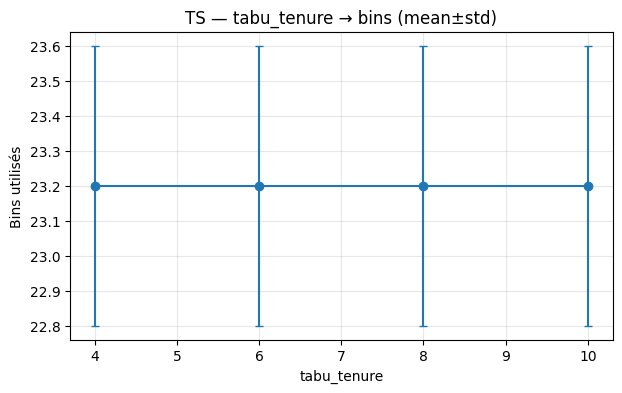

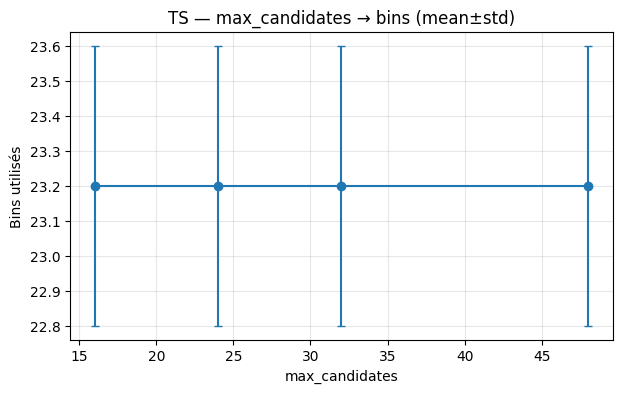

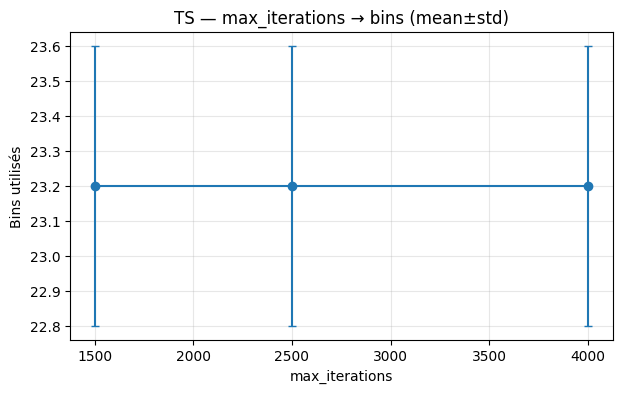

In [7]:
# ── Sensibilité : on varie 1 paramètre, les autres fixés au best ─────────────
ts_sens_rows: list[dict] = []
for param, values in TS_GRID.items():
    for v in values:
        params = dict(best_ts_params)
        params[param] = v

        df_runs = evaluate(
            method="TS",
            instances=tuning_instances,
            seeds=SEEDS,
            run_one=lambda inst, seed: run_tabu_custom(
                inst,
                seed,
                tabu_tenure=int(params["tabu_tenure"]),
                max_iterations=int(params["max_iterations"]),
                max_candidates=int(params["max_candidates"]),
            ),
        )
        ts_sens_rows.append({"param": param, "value": v, **summarize_runs(df_runs)})

ts_sensitivity = pd.DataFrame(ts_sens_rows)
display(ts_sensitivity)
plot_sensitivity(ts_sensitivity, title_prefix="TS — ")


---

## 6) À mettre dans le rapport

- Workload utilisé : `DATASET_KEY`, `MAX_ITEMS`, `N_INSTANCES`, `SEEDS`.
- Meilleurs hyperparamètres trouvés pour SA et TS.
- Les graphes de sensibilité (variation un par un).

Pour une étude plus solide : augmenter `N_INSTANCES` et `SEEDS`, ou tester plusieurs datasets.
